### Explore A Jain's IEI pipeline
### Julian Moran
### 2026-02-09

In [2]:
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Pipeline IO

Codebase at `/hpf/projects/CTrost/ajain/IEI_project/foldseek_AJ` 

1. DefenseFinder RefSeq IDs --> UniProt IDs
    - DefenseFinder: db of all bacterial genes implicated in antiphage systems
    - RefSeq bacterial accession IDs:   denote a bacterial immunoprotein; often begin with `WP`
    - UniProt access IDs:               denote a protein; e.g. `A0A7P0TAE1_HUMAN`

<br>

2. UniProt IDs --> Foldseek cluster ID

<br>

3. Foldseek cluster ID --> related human cluster ID

<br>

4. UniProt IDs --> UniprotKB annotations

<br>


# Questions

1. How does `01_RefSeq2Uniprot_mapping/` fit into the pipeline?
    - Are data in `01_RefSeq2Uniprot_mapping/` the output from pipeline step 2.?
    - Are data in `griid_gene_list/`, `gasdermin/`, `vipirin/`, `zorya/` prioritized subsets from `01_RefSeq2Uniprot_mapping/`?
    - If so, why are the subsets substantially larger than the original data?
    - `WP_063110969.1`, from `gasdermin/2025-07-26_gasdermin_annotated.xlsx`, is not in `data_local/01_RefSeq2Uniprot_mapping/2025-06-24_RefSeq2Uniprot_mapping.xlsx`

<br>

2. What is the relationship between each UniProt accession number and its corresponding cluster?
    - i.e. in datasets like `zorya/2025-07-27_zorya_annotated.tsv`?

<br>

3. Why do we see identical rows in the annotated data?
    - best to denote rows as `RefSeq_ID`,`UniProt_ID`,`FoldSeq_cluster`,`Similar_human_gene` 
    - e.g. in `zorya/2025-07-27_zorya_annotated.tsv`, see multiple rows for `WP_063192462.1`,`A0A142CZW3`,`A0A142CZW3`,`B4DLD8`

<br>

4. Human, Bacterial Domain Annotations ...
    - why is `Query_range` always a subset of the protein?
    - reading 1: `Query_range` is not an alignment subset because `Human_prot_domain_match` is in turn a subset of `Query_range` (same for `Target_range`, `Bacterial_prot_domain_match`)
    - reading 2: `*_range` annotations represent aligned sequences, and `*_domain` annotations represent something extraneous (e.g. sequence that matches documented bacterial domain) 
    - reading 2 is corroborated by our findings about the formula for `Overlap_ratio`

<br>


# Filtering criteria

1. Select for human proteins in same cluster as bacterial
    - `defense_system_cluster_id == cluster_id`
    - in annotated data, `defense_system_cluster_id` denotes the FoldSeek cluster that contains the query DefenseFinder protein
    - in annotated data, `cluster_id` denotes the most-similar target FoldSeek cluster containing a human protein 

<br>

2. Select for human proteins close in AA length to defense protein
    - col1: `Human_prot_total_length`
    - col2: `Bacterial_prot_total_length`
    - compute symmetric absolute percent difference (this appears to have been computed in `Overlap_ratio` col, albeit not symmetrically)
    - factor in percent overlap or percent match, here

<br>

3. Select for closest human genes that are in EAGLE definitive

<br>

# Plots

1. Heat map of e-values for strongly matching proteins

2. Histogram of AA length percent difference


In [28]:
# ============================================================
#                             Args
# ============================================================

args = {
    "data_file_ann_foldseek_uniprot": f"{INSTALL_PATH}/data_local/02_FoldSeek_Results_w_Uniprot_matches/2025-07-26_batch_0_annotated.tsv",
    "data_file_ann_eagle": f"{INSTALL_PATH}/data_sync/EAGLE_manual_scores.tsv",
    "data_file_GRIID": f"{INSTALL_PATH}/data_local/griid_gene_list/2025-07-30_data_filtered_for_griid_genes.tsv",
    "data_file_gasdermin": f"{INSTALL_PATH}/data_sync/gasdermin/2025-07-26_gasdermin_annotated.tsv",
    "data_file_vipirin": f"{INSTALL_PATH}/data_sync/viperin/2025-07-26_viperin_annotated.tsv",
    "data_file_zorya": f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv",
    "out_path_plots": f"{INSTALL_PATH}/plots",
    "var_name_lengthError": "Protein_length_error",
    "threshold_lengthError": 0.05,
    "threshold_overlapRatio": 0.9
}

In [31]:
# ============================================================
#                             In
# ============================================================

pl.Config.set_tbl_rows(10)

data_ann = {}
for key, path in args.items():
    if "data_file_" in key and not "_ann_" in key:
        data_key = key.replace("data_file_", "")
        data_ann[data_key] = pl.read_csv(
            args[key],
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df_foldseek_uniprot = pl.read_csv(
    args["data_file_ann_foldseek_uniprot"],
    separator="\t",
    has_header=True
)

df_eagle = pl.read_csv(
    args["data_file_ann_eagle"],
    separator="\t",
    has_header=True,
    encoding="latin1"
)

df_foldseek_uniprot

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,i64,f64
"""WP_001223208.1""","""MazEF""","""MazEF""","""Shigella dysenteriae,Escherich…","""GCF_003017995_NZ_CP027368_MazE…","""GCF_002156845.1_NZ_CP021339_05…","""GCF_019428585.1_NZ_CP080119_01…",671,6,"""A0A024L8H8""","""S3FMY0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,83,null,null,null,null,null,null,null,null,null
"""WP_003414296.1""","""Cas""","""CAS_Class1-Subtype-III-A""","""Mycobacterium tuberculosis,Myc…","""GCF_014884645_NZ_CP043996_CAS_…","""GCF_002975475.1_NZ_CP027035_02…","""GCF_013010385.1_NZ_CP053092_02…",264,23,"""A0A045ICU9""","""A0A1I6JKI6""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,124,null,null,null,null,null,null,null,null,null
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""A0A6J2X4D6""","""Q5TF85""",0.02082,1,0.098,297,214,0,179,475,10,247,0.001215,42,"""unreviewed""","""Q5TF85_HUMAN""","""polynucleotide adenylyltransfe…","""TENT5A FAM46A hCG_401094""","""Homo sapiens (Human)""",null,"""hCG_401094""","""TENT5A""","""FAM46A""","""UP000005640: Chromosome 6""",null,null,"""poly(A) RNA polymerase activit…","""poly(A) RNA polymerase activit…","""GO:1990817""",null,null,null,"""IPR012937; TET5.;""","""PTHR12974; PRION-LIKE- Q/N-RIC…","""PF07984; NTP_transf_7; 1.;""",null,"""SM01153; DUF1693; 1.;""",null,"""179.0..475.0""",297,523,null,null,null,null,null,null,"""10.0..247.0""",238,305,null,null,null,null,null,null,0.583174,238,0.780328
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""G1SF99""","""Q5VWP2""",0.08138,1,0.094,295,265,0,49,343,10,302,0.0009699,39,"""reviewed""","""TET5C_HUMAN""","""Terminal nucleotidyltransferas…","""TENT5C FAM46C""","""Homo sapiens (Human)""",null,null,"""TENT5C""","""FAM46C""","""UP000005640: Chromosome 1""","""in utero embryonic development…","""centrosome [GO:0005813]; cytop…","""centrosome [GO:0005813]; cytop…","""poly(A) RNA polymerase activit…","""GO:0001701; GO:0003723; GO

In [39]:
# ============================================================
#                 Clean, wrangle defense data
# ============================================================

def remove_dup_rows(df: pl.DataFrame) -> int:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count


data_cleaned = {}
for data_key, df in data_ann.items():
    data_cleaned[data_key], dups_count = remove_dup_rows(df)
    print(f"Number of dup rows in {data_key}: {dups_count:,}")

    # Write out cleaned version
    if dups_count > 0:
        key = [k for k in args if data_key in k][0]
        out_path = Path(args[key].replace(".tsv", "_cleaned.tsv"))
        data_cleaned[data_key].write_csv(
            out_path,
            separator="\t",
            include_header=True
        )

df_def_cleaned = pl.concat(
    [df for df in data_cleaned.values()],
    how="diagonal"
)

print(f"Number of rows after cleaning, v-stacking: {len(df_def_cleaned):,}")
df_def_cleaned

Number of dup rows in GRIID: 0
Number of dup rows in gasdermin: 0
Number of dup rows in vipirin: 266
Number of dup rows in zorya: 40,578
Number of rows after cleaning, v-stacking: 321,575


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_043041486.1""","""RM""","""RM_Type_III""","""Acinetobacter seifertii,Acinet…","""GCF_014722015_NZ_CP061646_RM_T…","""GCF_014722015.1_NZ_CP061646_03…","""GCF_004379355.1_NZ_CP038009_00…",2,201,"""A0A7H2V6W8""","""A0A174CCJ7""","""A0A821NB32""","""A0A2R8YDA1""",6.9340e-7,1,0.111,487,411,0.0,245,731,1,463,6.9630e-8,142,"""unreviewed""","""A0A2R8YDA1_HUMAN""","""SWI/SNF related, matrix associ…","""SMARCA4""","""Homo sapiens (Human)""",null,null,"""SMARCA4""",null,"""UP000005640: Chromosome 19""",null,"""chromosome [GO:0005694]; nucle…","""chromosome [GO:0005694]; nucle…","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd18062; DEXHc_SMARCA4; 1.;""cd…","""3.40.50.10810:FF:000008; Chrom…","""1.20.5.170; -; 1.;""3.40.5.120;…","""IPR030100; BRG1_ATP-bd.;""IPR00…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF07533; BRK; 1.;""PF00271; Hel…","""PS51192; HELICASE_ATP_BIND_1; …","""SM00592; BRK; 1.;""SM00487; DEX…",null,"""245.0..731.0""",487,985,"""262..427""",100.0,34.09,49.44,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""1.0..463.0""",463,895,"""8..249""",100.0,52.27,51.73,"""['Helicase/UvrB N-terminal']""","""['ECO:0000259|Pfam:PF04851']""",0.908629,463.0,0.517318,"""Yes"""
"""WP_003090158.1""","""CBASS""","""CBASS_III,CBASS_I""","""Pseudomonas nitroreducens,Pseu…","""GCF_023612335_NZ_CP069177_CBAS…","""GCF_009676885.1_NZ_CP046069_02…","""GCF_023612335.1_NZ_CP069177_04…",29,174,"""A0A6G6J0N3""","""A0A673YF76""","""A0A7N4NKQ5""","""V9HWK4""",0.000004,1,0.123,322,257,0.0,11,332,5,298,2.1810e-7,152,"""unreviewed""","""V9HWK4_HUMAN""","""Spermatid perinuclear RNA-bind…","""HEL162 STRBP hCG_31045""","""Homo sapiens (Human)""",null,"""hCG_31045""","""HEL162""","""STRBP""",null,"""cell motility [GO:0048870]; me…","""cytoplasm [GO:0005737]; manche…","""cytoplasm [GO:0005737]; manche…","""DNA binding [GO:0003677]; doub…","""GO:0002177; GO:0003677; GO:000…","""cd19897; DSRM_STRBP-like_rpt2;…","""1.10.1410.40:FF:000001; interl…","""1.10.1410.40; -; 1.;""3.30.160.…","""IPR014720; dsRBD_dom.;""IPR0065…","""PTHR45762:SF1; SPERMATID PERIN…","""PF00035; dsrm; 2.;""PF20965; DZ…","""PS50137; DS_RBD; 2.;""PS51703; …","""SM00358; DSRM; 2.;""SM00572; DZ…","""NP_060857.2; NM_018387.4.;""XP_…","""11.0..332.0""",322,672,"""5..363""",89.69,100.0,47.92,"""['DZF']""","""['ECO:0000259|PROSITE:PS51703'…","""5.0..298.0""",294,300,null,null,null,null,null,null,0.446429,294.0,0.98,"""No"""
"""WP_000102010.1""","""CBASS""","""CBASS_I""","""Salmonella sp. SAL-020,Salmone…","""GCF_012050745_NZ_CP050721_CBAS…","""GCF_017372215.1_NZ_CP071690_01…","""GCF_005889955.1_NZ_CP040644_01…",22,18

In [44]:
# ============================================================
#                    Wrangle defense data
# ============================================================

eagle_definitive = set(
    df_eagle.filter(
        pl.col("EAGLE Annotation").str.contains("Definitive")
    )["Gene"]
    .to_list()
)

print(f"N definitive EAGLE genes: {len(eagle_definitive)}")
eagle_definitive

N definitive EAGLE genes: 75


{'ADNP',
 'AHDC1',
 'ANKRD11',
 'ARHGEF9',
 'ARID1B',
 'ARX',
 'ASH1L',
 'ASXL3',
 'AUTS2',
 'BRAF',
 'CACNA1D',
 'CHD2',
 'CHD8',
 'CIC',
 'CNTN6',
 'CREBBP',
 'CSDE1',
 'CTNNB1',
 'CTTNBP2',
 'CUL3',
 'DDX3X',
 'DEAF1',
 'DIP2A',
 'DMD',
 'DNMT3A',
 'DSCAM',
 'DYNC1H1',
 'DYRK1A',
 'EHMT1',
 'EP300',
 'FOXP1',
 'GIGYF1',
 'GRIA2',
 'GRIN2B',
 'HNRNPU',
 'KDM6B',
 'KMT2A',
 'KMT2C',
 'KMT2E',
 'KMT5B',
 'MARK2',
 'MBD5',
 'MECP2',
 'MED13L',
 'MYT1L',
 'NAA15',
 'NCKAP1',
 'NIPBL',
 'NLGN4X',
 'NRXN1',
 'NSD1',
 'POGZ',
 'PTCHD1-AS',
 'PTEN',
 'RAI1',
 'RFX3',
 'SATB2',
 'SCN2A',
 'SETD5',
 'SHANK1',
 'SHANK2',
 'SHANK3',
 'SLC6A1',
 'SOX5',
 'STXBP1',
 'SYNGAP1',
 'TANC2',
 'TCF20',
 'TCF4',
 'TLK2',
 'TRIP12',
 'TSC1',
 'UBR5',
 'WAC',
 'WDFY3'}

In [40]:
# ============================================================
#                     Filter annotated data
# ============================================================

def filter_data(
        df: pl.DataFrame,
) -> pl.DataFrame:

    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    print(f"N rows after filtering: {len(df)}")

    return df

# What are the species annotations for closest match?
print("Unique values for col `Species` before filtering:")
print(df_def_cleaned["Organism"].unique())

df_def_filtered = filter_data(
    df=df_def_cleaned,
)
df_def_filtered

Unique values for col `Species` before filtering:
shape: (2,)
Series: 'Organism' [str]
[
	"Homo sapiens (Human)"
	null
]
N rows after filtering: 904


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_151137118.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas lalkuanensis""","""GCF_008807375_NZ_CP043311_Zory…","""GCF_008807375.1_NZ_CP043311_04…","""GCF_008807375.1_NZ_CP043311_04…",1,202,"""A0A5J6QTB0""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.203,579,442,0.0,472,1026,434,1012,6.8450e-26,849,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""472.0..1026.0""",555,1026,"""858..1010""",100.0,27.57,54.09,"""['Helicase C-terminal']""","""['ECO:0000255|PROSITE-ProRule:…","""434.0..1012.0""",579,1012,"""837..1005""",100.0,29.19,57.21,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.986355,555.0,0.548419,"""No"""
"""WP_015438307.1""","""RM""","""RM_Type_II""","""Bifidobacterium breve""","""GCF_002838425_NZ_CP021394_RM_T…","""GCF_002838425.1_NZ_CP021394_00…","""GCF_002838425.1_NZ_CP021394_00…",2,201,"""C1J0P2""","""A0A6I4ZMH2""","""A0A6I4ZMH2""","""B4DQZ2""",1.6640e-74,1,0.118,278,204,0.0,27,304,132,363,0.0001562,74,"""unreviewed""","""B4DQZ2_HUMAN""","""tRNA (cytosine(38)-C(5))-methy…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""methylation [GO:0032259]""",null,"""methyltransferase activity [GO…","""methyltransferase activity [GO…","""GO:0008168; GO:0032259""",null,"""3.90.120.10:FF:000005; tRNA (C…","""3.90.120.10; DNA Methylase, su…","""IPR050750; C5-MTase.;""IPR00152…","""PTHR46098; TRNA (CYTOSINE(38)-…","""PF00145; DNA_methylase; 1.;""","""PS00095; C5_MTASE_2; 1.;""",null,"""NP_001307935.1; NM_001321006.1…","""27.0..304.0""",278,310,null,null,null,null,null,null,"""132.0..363.0""",232,392,null,null,null,null,null,null,1.264516,232.0,0.748387,"""No"""
"""WP_016947078.1""","""Cas""","""CAS_Class1-Subtype-IV-A""","""Klebsiella pneumoniae,Klebsiel…","""GCF_002156785_NZ_CP020854_CAS_…","""GCF_003590665.1_NZ_CP031818_00…","""GCF_002180255.1_NZ_CP021699_00…",52,151,"""A0A2R4NGD3""","""A0A4Q9LAP2""","""A0A4Q9LAP2""","""A8MPP1""",0.0,1,0.104,868,537,0.0,20,887,15,614,1.3140e-17,407,"""reviewed""","""D11L8_HUM

In [ ]:
# ============================================================
#                Cross reference against EAGLE
# ============================================================

df_def_eagle = df_def_filtered.filter(
    pl.col("Gene names")
)



In [41]:
# ============================================================
#                        Compute new metrics
# ============================================================

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null() & pl.col(var_length_error).is_not_nan())
    )
    print(f"N of rows after filtering out nulls for extra metrics: {len(df):,}")
    return df

df_def_extra_metrics = add_annotations(
    df=df_def_filtered,
    var_length_error=args["var_name_lengthError"]
)

df_def_extra_metrics

N of rows after filtering out nulls for extra metrics: 868


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_error
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_151137118.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas lalkuanensis""","""GCF_008807375_NZ_CP043311_Zory…","""GCF_008807375.1_NZ_CP043311_04…","""GCF_008807375.1_NZ_CP043311_04…",1,202,"""A0A5J6QTB0""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.203,579,442,0.0,472,1026,434,1012,6.8450e-26,849,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""472.0..1026.0""",555,1026,"""858..1010""",100.0,27.57,54.09,"""['Helicase C-terminal']""","""['ECO:0000255|PROSITE-ProRule:…","""434.0..1012.0""",579,1012,"""837..1005""",100.0,29.19,57.21,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.986355,555.0,0.548419,"""No""",0.013645
"""WP_015438307.1""","""RM""","""RM_Type_II""","""Bifidobacterium breve""","""GCF_002838425_NZ_CP021394_RM_T…","""GCF_002838425.1_NZ_CP021394_00…","""GCF_002838425.1_NZ_CP021394_00…",2,201,"""C1J0P2""","""A0A6I4ZMH2""","""A0A6I4ZMH2""","""B4DQZ2""",1.6640e-74,1,0.118,278,204,0.0,27,304,132,363,0.0001562,74,"""unreviewed""","""B4DQZ2_HUMAN""","""tRNA (cytosine(38)-C(5))-methy…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""methylation [GO:0032259]""",null,"""methyltransferase activity [GO…","""methyltransferase activity [GO…","""GO:0008168; GO:0032259""",null,"""3.90.120.10:FF:000005; tRNA (C…","""3.90.120.10; DNA Methylase, su…","""IPR050750; C5-MTase.;""IPR00152…","""PTHR46098; TRNA (CYTOSINE(38)-…","""PF00145; DNA_methylase; 1.;""","""PS00095; C5_MTASE_2; 1.;""",null,"""NP_001307935.1; NM_001321006.1…","""27.0..304.0""",278,310,null,null,null,null,null,null,"""132.0..363.0""",232,392,null,null,null,null,null,null,1.264516,232.0,0.748387,"""No""",0.264516
"""WP_016947078.1""","""Cas""","""CAS_Class1-Subtype-IV-A""","""Klebsiella pneumoniae,Klebsiel…","""GCF_002156785_NZ_CP020854_CAS_…","""GCF_003590665.1_NZ_CP031818_00…","""GCF_002180255.1_NZ_CP021699_00…",52,151,"""A0A2R4NGD3""","""A0A4Q9LAP2""","""A0A4Q9LAP2""","""A8MPP1""",0.0,1,0.104,868,537,0.0,20,887,15,614

Protein_length_error max: 0.5168
Protein_length_error min: 0.001


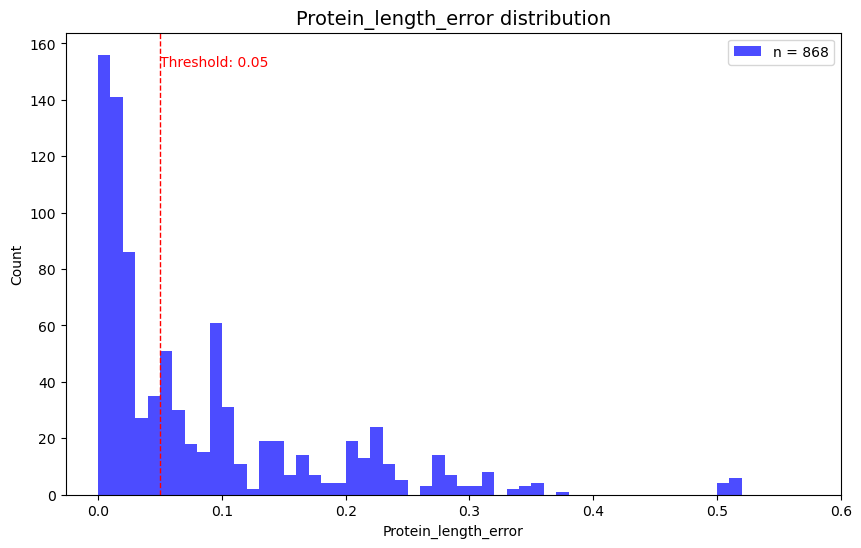

In [21]:
# ============================================================
#                  Plot: Protein length error
# ============================================================

# PLot histogram of `Protein_length_error`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:
    
    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    print(f"{col_name} max: {round(max, 4):,}")
    print(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        print(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        print(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha="left", va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_def_extra_metrics,
    col_name=args["var_name_lengthError"],
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{args['var_name_lengthError']} distribution",
    xlabel=args["var_name_lengthError"],
    out_path=f"{args['out_path_plots']}/hist_{args['var_name_lengthError']}",
    threshold=args["threshold_lengthError"]
)

# Overlap_ratio

From studying pattern the following dataset:
```
Query_length	Human_prot_total_length	Target_length	Bacterial_prot_total_length	Overlap_ratio
661	1026	696	1010	0.654455446
628	1014	637	1028	0.619329389
663	1014	620	971 0.638516993
546	1026	516	999	0.516516517
365	369	341	355	0.96056338
```

<br>

Formula for `Overlap_ratio`:
```Python
pl.col("Overlap_ratio") = (
    min([pl.col("Query_length"), pl.col("Target_length")]) 
    / min([pl.col("Human_prot_total_length"), pl.col("Bacterial_prot_total_length")])
)
```



Overlap_ratio max: 1.0
Overlap_ratio min: 0.1678


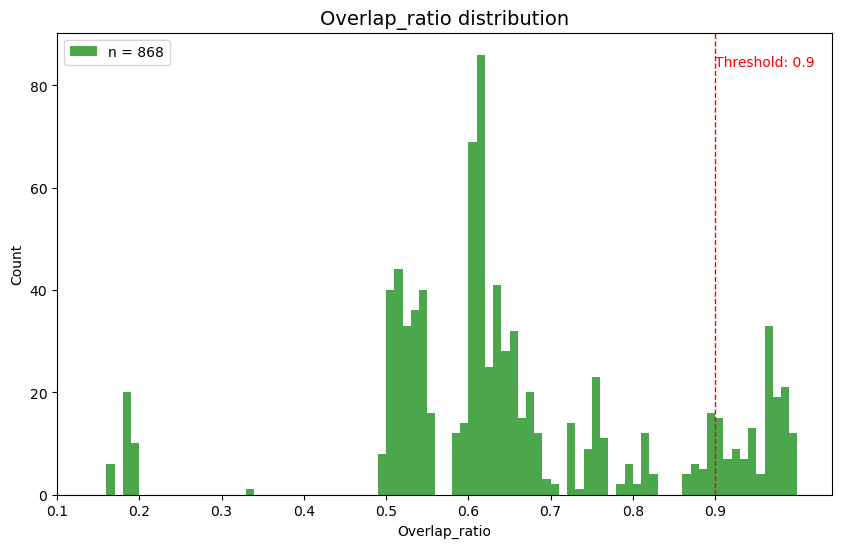

In [22]:
# ============================================================
#                   Plot: Overlap ratio
# ============================================================

plot_hist(
    df=df_def_extra_metrics,
    col_name="Overlap_ratio",
    colour="green",
    tick_interval=0.1,
    bin_width=0.01,
    title=f"Overlap_ratio distribution",
    xlabel="Overlap_ratio",
    out_path=f"{args['out_path_plots']}/hist_Overlap_ratio",
    threshold=args["threshold_overlapRatio"]
)


In [23]:
# ============================================================
#                   Filter by extra metrics
# ============================================================

def filter_extra_metrics(
        df: pl.DataFrame,
        var_length_error: str,
        threshold_length_error: float,
        threshold_overlap_ratio: float
) -> pl.DataFrame:
    
    df = df.filter(
        (pl.col(var_length_error) <= threshold_length_error) &
        (pl.col("Overlap_ratio") >= threshold_overlap_ratio)
    )

    print(f"N rows after filtering by extra metrics: {len(df)}")
    return df

df_filtered_extra = filter_extra_metrics(
    df=df_def_extra_metrics,
    var_length_error=args["var_name_lengthError"],
    threshold_length_error=args["threshold_lengthError"],
    threshold_overlap_ratio=args["threshold_overlapRatio"]
)

df_filtered_extra

N rows after filtering by extra metrics: 34


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_error
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_004268761.1""","""Wadjet""","""Wadjet_I""","""Bifidobacterium animalis""","""GCF_015377505_NZ_CP045589_Wadj…","""GCF_021018785.1_NZ_CP085838_00…","""GCF_002220485.1_NZ_CP017098_00…",9,194,"""A0A806FWR7""","""A0A4P9X374""","""A0A4P9X374""","""B3KMB1""",0.0,1,0.123,1184,1004,0.0,3,1186,20,1165,2.0310e-23,280,"""unreviewed""","""B3KMB1_HUMAN""","""Structural maintenance of chro…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""cell division [GO:0051301]; ch…","""chromosome [GO:0005694]; nucle…","""chromosome [GO:0005694]; nucle…","""ATP binding [GO:0005524]; ATP …","""GO:0005524; GO:0005694; GO:001…","""cd03273; ABC_SMC2_euk; 1.;""","""1.20.1060.20:FF:000005; Struct…","""1.20.1060.20; -; 1.;""3.30.70.1…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR43977; STRUCTURAL MAINTENA…","""PF06470; SMC_hinge; 1.;""PF0246…",null,"""SM00968; SMC_hinge; 1.;""","""NP_001036015.1; NM_001042550.1…","""3.0..1186.0""",1184,1197,"""520..640""",100.0,10.22,98.91,"""['SMC hinge']""","""['ECO:0000259|SMART:SM00968']""","""20.0..1165.0""",1146,1165,null,null,null,null,null,null,0.9732665,1146.0,0.983691,"""No""",0.026734
"""WP_016190710.1""","""RM""","""RM_Type_II""","""Erwinia tracheiphila""","""GCF_021365505_NZ_CP089940_RM_T…","""GCF_021365465.1_NZ_CP089932_04…","""GCF_021365505.1_NZ_CP089940_04…",2,201,"""A0A0M2KG49""","""A0A6I4ZMH2""","""A0A6I4ZMH2""","""O14717""",1.6640e-74,2,0.16,388,299,0.0,3,390,11,367,2.2700e-15,332,"""reviewed""","""TRDMT_HUMAN""","""tRNA (cytosine(38)-C(5))-methy…","""TRDMT1 DNMT2""","""Homo sapiens (Human)""",null,null,"""TRDMT1""","""DNMT2""","""UP000005640: Chromosome 10""","""tRNA methylation [GO:0030488];…","""cytoplasm [GO:0005737]; nucleo…","""cytoplasm [GO:0005737]; nucleo…","""RNA binding [GO:0003723]; tRNA…","""GO:0003723; GO:0005634; GO:000…","""cd00315; Cyt_C5_DNA_methylase;…","""3.40.50.150:FF:000285; tRNA (c…","""3.90.120.10; DNA Methylase, su…","""IPR050750; C5-MTase.;""IPR00152…","""PTHR46098; TRNA (CYTOSINE(38)-…","""PF00145; DNA_methylase; 1.;""","""PS00095; C5_MTASE_2; 1.;""PS516…",null,"""NP_001307935.1; NM_001321006.1…","""3.0..390.0""",388,391,"""4..391""",99.74,99.74,99.23,"""['SAM-dependent MTase C5-type'…","""['ECO:0000255|PROSITE-ProRule:…","""11.0..367.0""",357,379,null,null,null,null,null,null,0.969309,357.0,0.941953,"""No""",0.030691
"""WP_004268761.1""","""Wadjet""","""Wadjet_I""","""Bifidobacterium animalis""","""GCF_015377505_NZ_CP045589_Wadj…","""GCF_021018785.1_NZ_CP085838_00…","""GCF_002220485.1_NZ_CP017098_00…",9,194,"""A0A806FWR7""","""A0A4P9X374""","""A0A4P9X374""","""A8K984""",0.0,1,0.12,1187,1008,0.0,3,1189,20,1

# To do

1. Cross-reference against EAGLE definitive genes

<br>

2. Filter by e-value
- understand e-values